In [1]:
import random
import numpy as np
import os
from os import path
import time
import copy
import torch
from torch import nn
from gan_training.utils4nb import return_data_test
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from gan_training import utils
from gan_training.train import Trainer, update_average
from gan_training.logger import Logger
from gan_training.checkpoints import CheckpointIO
from gan_training.inputs import get_dataset
from gan_training.distributions import get_ydist, get_zdist
from gan_training.eval_test import DisentEvaluator, Evaluator
from gan_training.config4nb import (
    load_config, build_models, build_optimizers, build_lr_scheduler,
)


C:\Users\Rashmi\Anaconda\envs\torch-gpu\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# Arguments

#args.config_dir='./configs'
config='cells_650.yaml'
VAEname= 'FactorVAE3'
#VAEname='BetaVAE_H'
chkptname= 'last'
config_dir='./configs'
output_dir= './outputs/'
#dvae_name= None
                   


In [3]:
#LC-136
#CellCycle-
#CPA-176-
#EMT-164-
#LiveCell -157


config_path = os.path.join(config_dir, config)
config = load_config(config_path)

nf=-1 #Base number of filters


bs=1 #'Batch size'
reg_param=-1 #'R1 regularization parameter'
w_info =-1#'weighting constant on ID Loss')
mi=max_iter=-1 #'Max training iteration')
num_workers=0 #'dataloader num_workers'
#batch_size=32 # help='batch size'

image_size= 256         #  Image size
dset_dir='./ProcessedData/'
datatype='rgb'
nc= 3

#parser.add_argument('--img_size', default=128, type=int, help='Image synthesis size')##This is the image size for which the autoencoder is designed to


c_dim= 10 #Latent synthesis size'
z_dim=256 #type=int, help='Image synthesis size')

no_cuda=False #help='Do not use cuda')
seed=1 #type=int, help='Random Seed')
infodistil_mode=True #'Infodistill')
#args = parser.parse_args()

#dvae_name='cells_trial_factor176' 
#name='GAN_Trial176_1'
TrainDataset='LC' # Example LC, EMT, CPA
TestDataset='LC/Selected/'
Model_dir='./Models'
dset_dir='./ProcessedData/'
#config_path = os.path.join(config_dir, config)
is_cuda = (torch.cuda.is_available() and not no_cuda)


In [4]:
VAE_chkptname='last'
GAN_chkptname='model.pt'
data_dir=os.path.join(dset_dir,TestDataset)
#out_dir = os.path.join(output_dir, name)
fvae_ckpt_path = os.path.join(Model_dir, TrainDataset, 'VAE','chkpts',VAE_chkptname)
gan_ckpt_path = os.path.join(Model_dir, TrainDataset, 'GAN','chkpts')
     


In [5]:

# Logger
checkpoint_io = CheckpointIO(
    checkpoint_dir=gan_ckpt_path
)

device = torch.device("cuda:0" if is_cuda else "cpu")

train_dataset = get_dataset(
    name='image',
    data_dir=data_dir,
    size=image_size,
)
train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=bs,
        num_workers=3,
        shuffle=True, pin_memory=True, sampler=None, drop_last=True
)



In [6]:
device = torch.device("cuda:0" if is_cuda else "cpu")
device

device(type='cuda', index=0)

In [7]:


#Create models
fvae, generator, discriminator = build_models(image_size, c_dim, nc, z_dim)
data_loader = return_data_test(TestDataset, datatype, dset_dir, bs, image_size)



In [8]:
selectVAE='fvae'

if selectVAE=='dvae':
    dvae_ckpt_path =  os.path.join()

    dvae_ckpt = torch.load(dvae_ckpt_path)
    #for key in list(dvae_ckpt_path.keys()):
    #    dvae_ckpt_path[key.replace('decoder.', 'module.decoder.'). replace('encoder.', 'module.encoder.')] = dvae_ckpt_path.pop(key)

    dvae.load_state_dict(dvae_ckpt_path)
else:

    #fvae_ckpt_path = os.path.join(output_dir, dvae_name,'chkpts', chkptname)

    fvae_ckpt = torch.load(fvae_ckpt_path)

    for key in list(fvae_ckpt['model_states']['VAE'].keys()):
        fvae_ckpt['model_states']['VAE'][key.replace('decode.', 'decoder.layer.').
                                         replace('decode.', 'decoder.layer.').
                                         replace('decode.', 'decoder.layer.').
                                         replace('decode.', 'decoder.layer.').
                                         replace('decode.', 'decoder.layer.').
                                         replace('encode.', 'encoder.layer.').
                                         replace('encode.', 'encoder.layer.').
                                         replace('encode.', 'encoder.layer.').
                                         replace('encode.', 'encoder.layer.').
                                         replace('encode.', 'encoder.layer.')] = fvae_ckpt['model_states']['VAE'].pop(key)


    fvae.load_state_dict(fvae_ckpt['model_states']['VAE'])

    dvae=fvae


In [9]:
# Put models on gpu if needed
dvae = dvae.to(device)
generator = generator.to(device)
discriminator = discriminator.to(device)

#g_optimizer, d_optimizer = build_optimizers(
#    generator, discriminator, dvae, config
#)

# Use multiple GPUs if possible
dvae = nn.DataParallel(dvae)
generator = nn.DataParallel(generator)
discriminator = nn.DataParallel(discriminator)

In [10]:

# Register modules to checkpoint
checkpoint_io.register_modules(
    generator=generator,
    discriminator=discriminator,

)

# Logger
logger = Logger(
    log_dir=path.join(output_dir, 'logs'),
    img_dir=path.join(output_dir, 'imgs'),
    #monitoring=config['training']['monitoring'],
    #monitoring_dir=path.join(out_dir, 'monitoring')
)


# Distributions
cdist = get_zdist('gauss',c_dim, device=device)
zdist = get_zdist('gauss', z_dim,
                  device=device)

 
# Save for tests
ntest = bs
#x_real, ytest = utils.get_nsamples(train_loader, ntest)
ztest = zdist.sample((ntest,))
ctest = cdist.sample((ntest,))
ztest_ = torch.cat([ztest, ctest], 1)

In [11]:



generator_test = generator

# Evaluator
dis_evaluator = DisentEvaluator(generator=generator_test, zdist=zdist, cdist=cdist,
                                batch_size=bs, device=device, dvae=dvae)
#data_loader = return_data_test()

# Train
tstart = t0 = time.time()
it = epoch_idx = -1

In [12]:
# Load checkpoint if existant
it = checkpoint_io.load('model.pt')
#if it != -1:
#   logger.load_stats('stats.p')
# Training loop


=> Loading checkpoint...


In [13]:
epoch_idx=0
mu_real_Dump=[]
mu_gen_Dump=[]
mu_real_All=[]
mu_gen_All=[]
label1=[]
label2=[]
label3=[]
travN_MainDir='./outputs/TraversalLoop/'
#travN_MainDir= 'Z:/COVID-FTP/Rashmi/IDGAN/outputs/'
Traverse=True # Set flag to True if you wish to save traversal images to generate interpretation heatmap else set to False 



In [14]:
t = time.time()
for x_true, path, label in data_loader:
    epoch_idx += 1

    #for x_real, _ in train_loader:
    
    x_true=x_true.to(device)

    mu_real, logvar, c_real = fvae(x_true, encode_only=True)
    #print(c_real)
    
    recon_img=dis_evaluator.predict_image(c_real)
    recon_img=torch.stack(recon_img)
    mu_gen, logvar_gen, c_gen=fvae(recon_img, encode_only=True)
    
    mu_real_All.append(mu_real.detach().cpu())
    mu_gen_All.append(mu_gen.detach().cpu())
    
    
    mu, c_lat=dis_evaluator.predict_latent(x_true)
    if Traverse==True:
        if epoch_idx < 50:
        
            travN =  epoch_idx
            travN_dir = os.path.join(travN_MainDir, str(travN))
            #print('checkpoint_dir',checkpoint_dir)
            # Create missing directories
            if not os.path.exists(travN_dir):
                os.makedirs(travN_dir)
                
            c_lat_sample=c_lat
            z_sample=ztest[0]
            #c_lat_sample=c_lat_sample.unsqueeze(0)
            z_sample=z_sample.unsqueeze(0)
            travN
            ncol=dis_evaluator.traverse_c1z1(travN, z_sample, c_lat_sample, save=Traverse, save_type='dvae', TravImRet=Traverse, cmap='viridis')
            print('Saving Traversal Images')
    print(epoch_idx)
## Sorting the feature tables according to order generated in the ImageGenerator 

    label1.append(label)
    L1=os.path.split(path[0])
    L2=os.path.basename(path[0])

    Name=L2[0]
    label2.append(Name[0])
    label3.append(path)

            
    # do stuff
elapsed = time.time() - t
print('Time taken to complete testing this dataset=')
print(elapsed)

Saving Traversal Images
1
Saving Traversal Images
2
Saving Traversal Images
3
Saving Traversal Images
4
Saving Traversal Images
5
Saving Traversal Images
6
Saving Traversal Images
7
Saving Traversal Images
8
Saving Traversal Images
9
Saving Traversal Images
10
Saving Traversal Images
11
Saving Traversal Images
12
Saving Traversal Images
13
Saving Traversal Images
14
Saving Traversal Images
15
Saving Traversal Images
16
Saving Traversal Images
17
Saving Traversal Images
18
Saving Traversal Images
19
Saving Traversal Images
20
Saving Traversal Images
21
Saving Traversal Images
22
Saving Traversal Images
23
Saving Traversal Images
24
Saving Traversal Images
25
Saving Traversal Images
26
Saving Traversal Images
27
Saving Traversal Images
28
Saving Traversal Images
29
Saving Traversal Images
30
Saving Traversal Images
31
Saving Traversal Images
32
Saving Traversal Images
33
Saving Traversal Images
34
Saving Traversal Images
35
Saving Traversal Images
36
Saving Traversal Images
37
Saving Tra

1631
1632
1633
1634
1635
1636
1637
1638
1639
1640
1641
1642
1643
1644
1645
1646
1647
1648
1649
1650
1651
1652
1653
1654
1655
1656
1657
1658
1659
1660
1661
1662
1663
1664
1665
1666
1667
1668
1669
1670
1671
1672
1673
1674
1675
1676
1677
1678
1679
1680
1681
1682
1683
1684
1685
1686
1687
1688
1689
1690
1691
1692
1693
1694
1695
1696
1697
1698
1699
1700
1701
1702
1703
1704
1705
1706
1707
1708
1709
1710
1711
1712
1713
1714
1715
1716
1717
1718
1719
1720
1721
1722
1723
1724
1725
1726
1727
1728
1729
1730
1731
1732
1733
1734
1735
1736
1737
1738
1739
1740
1741
1742
1743
1744
1745
1746
1747
1748
1749
1750
1751
1752
1753
1754
1755
1756
1757
1758
1759
1760
1761
1762
1763
1764
1765
1766
1767
1768
1769
1770
1771
1772
1773
1774
1775
1776
1777
1778
1779
1780
1781
1782
1783
1784
1785
1786
1787
1788
1789
1790
1791
1792
1793
1794
1795
1796
1797
1798
1799
1800
1801
1802
1803
1804
1805
1806
1807
1808
1809
1810
1811
1812
1813
1814
1815
1816
1817
1818
1819
1820
1821
1822
1823
1824
1825
1826
1827
1828
1829
1830


3278
3279
3280
3281
3282
3283
3284
3285
3286
3287
3288
3289
3290
3291
3292
3293
3294
3295
3296
3297
3298
3299
3300
3301
3302
3303
3304
3305
3306
3307
3308
3309
3310
3311
3312
3313
3314
3315
3316
3317
3318
3319
3320
3321
3322
3323
3324
3325
3326
3327
3328
3329
3330
3331
3332
3333
3334
3335
3336
3337
3338
3339
3340
3341
3342
3343
3344
3345
3346
3347
3348
3349
3350
3351
3352
3353
3354
3355
3356
3357
3358
3359
3360
3361
3362
3363
3364
3365
3366
3367
3368
3369
3370
3371
3372
3373
3374
3375
3376
3377
3378
3379
3380
3381
3382
3383
3384
3385
3386
3387
3388
3389
3390
3391
3392
3393
3394
3395
3396
3397
3398
3399
3400
3401
3402
3403
3404
3405
3406
3407
3408
3409
3410
3411
3412
3413
3414
3415
3416
3417
3418
3419
3420
3421
3422
3423
3424
3425
3426
3427
3428
3429
3430
3431
3432
3433
3434
3435
3436
3437
3438
3439
3440
3441
3442
3443
3444
3445
3446
3447
3448
3449
3450
3451
3452
3453
3454
3455
3456
3457
3458
3459
3460
3461
3462
3463
3464
3465
3466
3467
3468
3469
3470
3471
3472
3473
3474
3475
3476
3477


4917
4918
4919
4920
4921
4922
4923
4924
4925
4926
4927
4928
4929
4930
4931
4932
4933
4934
4935
4936
4937
4938
4939
4940
4941
4942
4943
4944
4945
4946
4947
4948
4949
4950
4951
4952
4953
4954
4955
4956
4957
4958
4959
4960
4961
4962
4963
4964
4965
4966
4967
4968
4969
4970
4971
4972
4973
4974
4975
4976
4977
4978
4979
4980
4981
4982
4983
4984
4985
4986
4987
4988
4989
4990
4991
4992
4993
4994
4995
4996
4997
4998
4999
5000
5001
5002
5003
5004
5005
5006
5007
5008
5009
5010
5011
5012
5013
5014
5015
5016
5017
5018
5019
5020
5021
5022
5023
5024
5025
5026
5027
5028
5029
5030
5031
5032
5033
5034
5035
5036
5037
5038
5039
5040
5041
5042
5043
5044
5045
5046
5047
5048
5049
5050
5051
5052
5053
5054
5055
5056
5057
5058
5059
5060
5061
5062
5063
5064
5065
5066
5067
5068
5069
5070
5071
5072
5073
5074
5075
5076
5077
5078
5079
5080
5081
5082
5083
5084
5085
5086
5087
5088
5089
5090
5091
5092
5093
5094
5095
5096
5097
5098
5099
5100
5101
5102
5103
5104
5105
5106
5107
5108
5109
5110
5111
5112
5113
5114
5115
5116


In [15]:

label1=np.hstack(label1)
label2=np.hstack(label2)
label3=np.hstack(label3)

mu_real_All=np.vstack(mu_real_All)
LatentZ=pd.DataFrame(mu_real_All)

#Save Predicted Latent Features
#LatentZ.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Latent_EMT_Lineage2.csv')
#LabelAll=pd.DataFrame(label1)
#LabelAll.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Label_EMT_lineage2.csv')
#LabelAll=pd.DataFrame(label2)
#LabelAll.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Label_EMT_Lineage_Cond2.csv')
#LabelAll=pd.DataFrame(label3)
#LabelAll.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Label_EMT_Lineages_Paths2.csv')'''



In [16]:
embedding=dis_evaluator.reduce_latent2d(dis_evaluator.normalize_matrix(mu_real_All), dim_red='umap')


In [17]:
sns.set(font_scale = 5)
#data_real=np.hstack((embedding, labelAll[:]))
df1 = pd.DataFrame(embedding, columns=['X','Y'])
df2 = pd.DataFrame(label1, columns=['ClassLabels1'])
df3 = pd.DataFrame(label2, columns=['ClassLabels2'])
df_F=pd.concat([df1, df2, df3],axis=1)

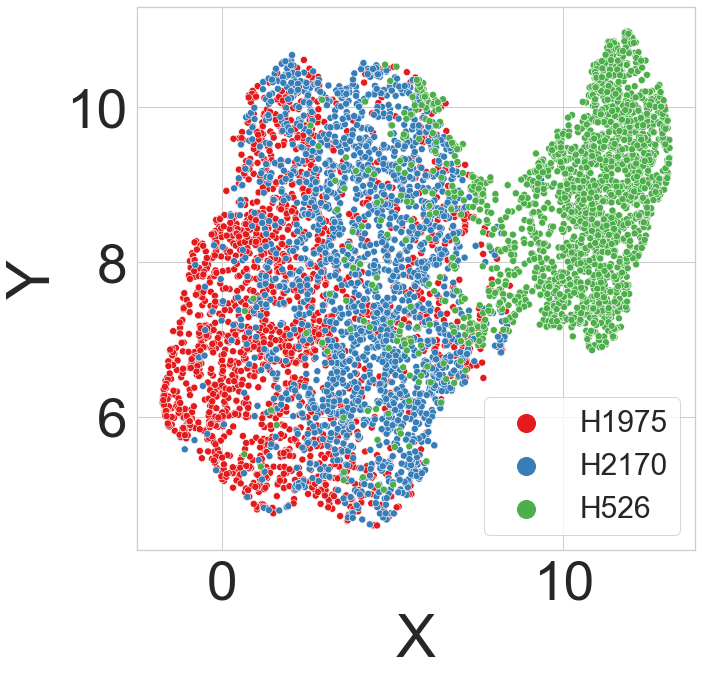

In [18]:
plt.figure(figsize=(10,10))
#plt.axis('off')
sns.set_style("whitegrid")

sns.scatterplot(data=df_F, x="X", y="Y", s=50, hue="ClassLabels1", palette=('Set1'))
plt.legend(markerscale=3, fontsize=30)

In [22]:
mu_real_All.shape

(5997, 10)

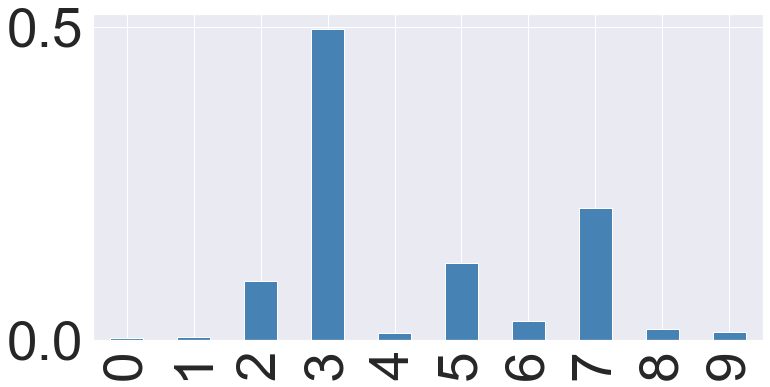

Accuracy: 0.815


In [23]:

sns.set(font_scale=5)

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import pandas as pd
plt.grid(None)
#plt.axis('off')


# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(mu_real_All, label1, test_size=0.2, random_state=1)
clf = DecisionTreeClassifier(criterion='gini', max_depth=7)
clf.fit(X_train, y_train)  # celltype
pd.Series(clf.feature_importances_, index=LatentZ.columns).plot.bar(color='steelblue', figsize=(12, 6))
plt.show()
y_pred = clf.predict(X_test)


print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

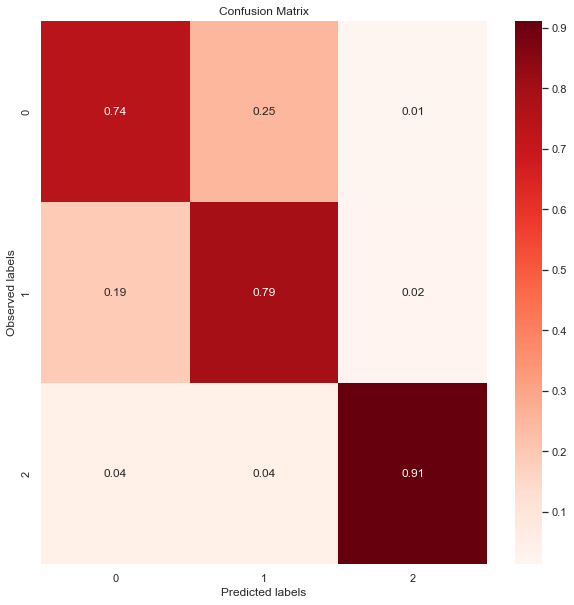

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix,plot_confusion_matrix
plt.figure(figsize=(10,10))
ax = plt.subplot()

sns.set(font_scale=1.0) # Adjust to fit
y_pred= clf.predict(X_test)

cm=confusion_matrix(y_test, y_pred)

df=pd.DataFrame(cm)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cmn, annot=True, fmt='.2f', ax=ax, cmap="Reds");  # annot=True to annotate cells

#plt.axis('off')

# labels, title and ticks
ax.set_xlabel('Predicted labels');
ax.set_ylabel('Observed labels');
ax.set_title('Confusion Matrix');
#ax.xaxis.set_ticklabels(label1);
#ax.yaxis.set_ticklabels(label1);


plt.show()